In [21]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import tarfile
from scipy.spatial import procrustes
from scipy.spatial import KDTree


In [22]:
################################
# type funcs
################################
def get_cell_type(cell_id):
    p = cell_id // 2
    part = cell_id % 2  # 0=.re, 1=.im

    if p % 3 == 0:
        return 2 if part == 0 else 5
    elif p % 3 == 1:
        return 3 if part == 0 else 4
    else:
        return 1 if part == 0 else 6


def get_cell_type_TS(cell_id):
    p = cell_id // 2
    part = cell_id % 2  # 0=.re, 1=.im

    if p % 3 == 0:
        return 5 if part == 0 else 2
    elif p % 3 == 1:
        return 4 if part == 0 else 3
    else:
        return 6 if part == 0 else 1





 # Bundle metrics, centers and spacing - individual runs

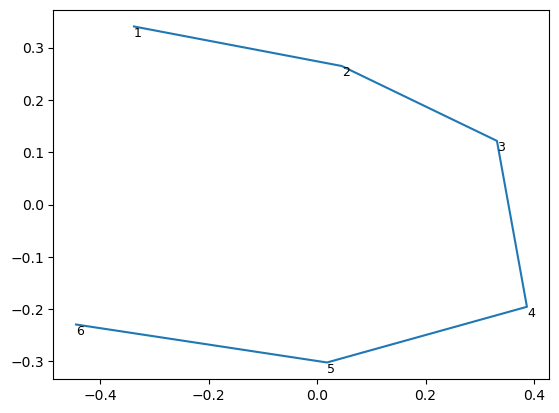

In [23]:
################################
#reference shape (local)
################################
#from data
# x_compare = [-0.337638, 0.045318, 0.331642, 0.386951, 0.018275, -0.444548]
# y_compare = [-0.340506, -0.264926, -0.121715, 0.195594, 0.302092, 0.229461]

#from data
x_compare = [-0.444548, 0.018275, 0.386951, 0.331642, 0.045318, -0.337638]
y_compare = [-0.229461, -0.302092, -0.195594, 0.121715, 0.264926, 0.340506]

#ref_ts = np.array([1, 2, 3, 4, 5, 6])
ref_ts=np.array([6,5,4,3,2,1])
ref_order = np.argsort(ref_ts)

xs_ref = np.array(x_compare)[ref_order]
ys_ref = np.array(y_compare)[ref_order]
ref_ts =np.array(ref_ts)[ref_order]
reference_hex = list(zip(xs_ref, ys_ref))
ref = np.array(reference_hex)

plt.plot(xs_ref, ys_ref)
for t, x, y in zip(ref_ts, xs_ref, ys_ref):
    plt.text(x, y, str(t), fontsize=9, ha="left", va="top")
################################
#reference shape (global)
################################
# bio grid

normal_bio = pd.read_csv("bundle_centers_bio2.csv")
normal_bio_fl = normal_bio.copy()

normal_bio_fl["y_flip"] = - normal_bio_fl["y"]
bundle_cs_f = normal_bio_fl[["x", "y_flip"]].to_numpy()



In [5]:
xs_ref

array([-0.337638,  0.045318,  0.331642,  0.386951,  0.018275, -0.444548])

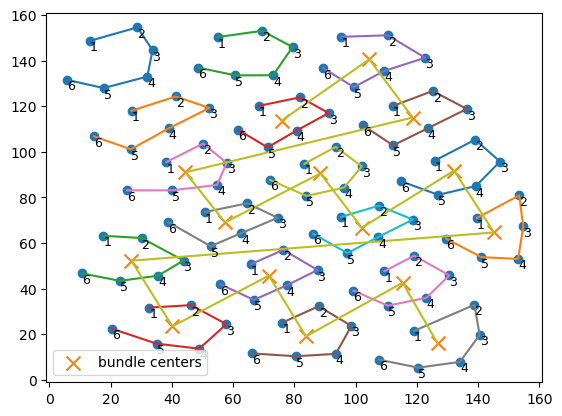

local dissim: 0.140604868238162
global dissim: 0.06812214901867386


In [174]:

# One file w plots

# FRAMES_DIR = Path( r"E:\MASTER THESIS\code\out_debug_ver2b_576_3_6_15_2_2_1.5")
#TAR_PATH = Path(r"E:\MASTER THESIS\code\ver2b sweeps\D-27\out_debug_ver2b_adh27_D_16_3_6_5_2_7_0.21899544273840021.tar.gz")
TAR_PATH= Path(r"E:\MASTER THESIS\code\diagnostics\out_debug_unity _interact_3_6_15_2_2_1.5.tar.gz") #folders of .tar.gz runs
end_frame = 45
NX = 512
dx = 0.3125

PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

xs = []
ys = []
ts = []
bs = []


################################
#for tar file
################################
with tarfile.open(TAR_PATH, "r:gz") as tar:

    cells = [
        member for member in tar.getmembers()
        if member.isfile()
        and Path(member.name).name.startswith("rho")
        and Path(member.name).name.endswith(f"-t{end_frame}.txt")
    ]

    ################################
    # for every cell field
    ################################
    for cell in cells:

        fname = Path(cell.name).name

        m = re.search(PATTERN_RHO, fname)
        if not m:
            continue

        f = tar.extractfile(cell)
        rho = np.loadtxt(f)
        total_mass = np.sum(rho)

        if total_mass == 0 or not np.isfinite(total_mass):
            continue

        x_cm = np.sum(x_scaled * rho) / total_mass
        y_cm = np.sum(y_scaled * rho) / total_mass

        cell_id = int(m.group(1))

        xs.append(x_cm)
        ys.append(y_cm)
        ts.append(get_cell_type_TS(cell_id))
        bs.append(cell_id // 6)

################################
# all cell data is loaded
################################
xs = np.array(xs)
ys = np.array(ys)
ts = np.array(ts)
bs = np.array(bs)

selected_bundles = {3, 7, 8, 9, 14, 16}
bundle_centers = []
dissim = []
bundle_ids = []

plt.scatter(xs, ys)

################################
# for every bundle
################################
for bundle in sorted(set(bs)):
    # if bundle not in selected_bundles:
    #     continue
    mask = bs == bundle

    xs_b = xs[mask]
    ys_b = ys[mask]
    ts_b = ts[mask]

    order = np.argsort(ts_b)

    xs_sorted = xs_b[order]
    ys_sorted = ys_b[order]
    ts_sorted = ts_b[order]

    figure_bundle = list(zip(xs_sorted, ys_sorted))
    model = np.array(figure_bundle)

    # Plot cells and bundle shape
    for t, x_pos, y_pos in zip(ts_sorted, xs_sorted, ys_sorted):
        plt.text(x_pos, y_pos,str(t),fontsize=9,ha="left",va="top")

    plt.plot(xs_sorted, ys_sorted)

    #skip broken bundles
    if (model.shape != ref.shape or not np.isfinite(model).all() or len(np.unique(model, axis=0)) != 6):
        dissim.append(np.nan)
        continue

    # Local metric
    ref_aligned, model_aligned, disparity = procrustes(ref, model)
    dissim.append(disparity)

    bundle_ids.append(bundle)
    bundle_centers.append([ np.mean(xs_b), np.mean(ys_b)])

################################
# global metric
################################
bundle_centers = np.array(bundle_centers)

# Remove  bundle if required for this grid
bundle_centers = bundle_centers[3:].copy()

if bundle_centers.shape == bundle_cs_f.shape:

        run, bio_fl, _ = procrustes(bundle_centers, bundle_cs_f)
        
        tree = KDTree(np.c_[bio_fl[:, 0], bio_fl[:, 1]])
        distances1, _ = tree.query(np.c_[run[:, 0],run[:, 1]], k=1) 
        
        tree = KDTree(np.c_[run[:, 0], run[:, 1]])
        distances2, _ = tree.query(np.c_[bio_fl[:, 0],bio_fl[:, 1]], k=1) 
        all_distances = np.concatenate([distances1, distances2])
        global_dissim= np.mean(all_distances)
        global_dissim_sd= np.std(all_distances)

else:
    global_dissim = np.nan
    global_dissim_sd = np.nan

################################
# plot
################################
plt.scatter(bundle_centers[:, 0],bundle_centers[:, 1],marker="x", s=100, label="bundle centers")
plt.plot( bundle_centers[:, 0], bundle_centers[:, 1])

plt.xlim(-1, NX*dx + 1)
plt.ylim(-1, NX*dx + 1)

plt.legend()
plt.show()

print("local dissim:", np.nanmean(dissim))
print("global dissim:", global_dissim)

In [28]:
print("local dissim:", np.nanstd(dissim))

local dissim: 0.031689233627907286


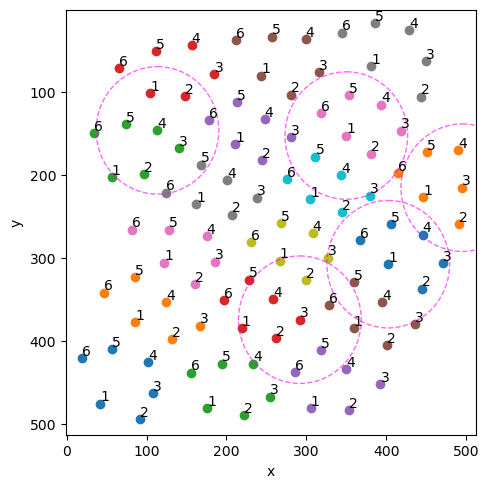

In [175]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(5, 5))

groups = np.asarray(bs)   
for g in np.unique(groups):
    mask = groups == g
    plt.scatter( xs[mask]/dx, ys[mask]/dx)
    
#types
for x, y, t in zip(xs, ys, ts):
    plt.text(x/dx, y/dx, str(t), fontsize=10, ha="left", va="bottom")
#local box radius (interaction)
for i in [3, 77,33, 23, 90]: #some random PRs
    ax.add_patch(Circle( (xs[i]/dx, ys[i]/dx), 24/dx,fill=False,ls="--",color="magenta", alpha=0.6))

#unity 24
#smal 20
#big 30
# plt.xlim(-1,NX*dx + 1)
# pl.ylim(-1,NX*dx + 1)
plt.xlim(-1,NX + 1)
plt.ylim((NX + 1),1)
plt.xlabel("x")
plt.ylabel("y")
#plt.title("Interaction Range Diagnostic")

plt.tight_layout()
plt.show()

In [ ]:
# Used in bio-metric as test
#bundle_centers_df = pd.DataFrame({
#     "bundle": bundle_ids,
#     "x": bundle_centers[:, 0],
#     "y": bundle_centers[:, 1],
# })
# 
# out_path = f"bundle_centers_pde.csv"
# bundle_centers_df.to_csv(out_path, index=False)
# 
# print("saved bundle centers to:", out_path)

 # Interface

################### 17


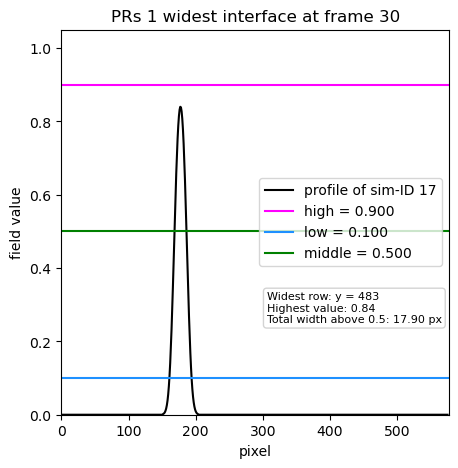

################### 19


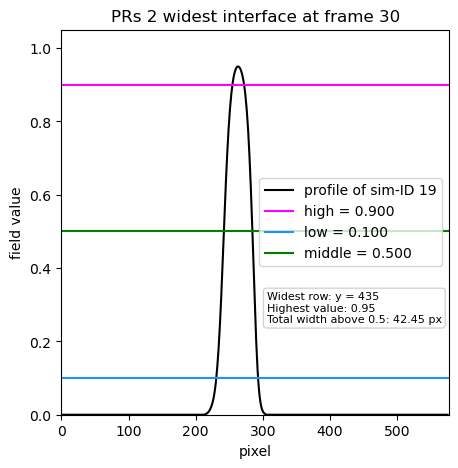

30.17604284062267


In [142]:
end_frame = 30
cell_id = [17,19] #bundle in the middle ,20,21,22,23

NX = 576
dx = 0.3125

# FRAMES_DIR = Path(r"E:\MASTER THESIS\code\out_debug_ver2b_CLAMP_3_6_5_8_8_0.2")
TAR_PATH = Path( r"E:\MASTER THESIS\code\ver2b sweeps\Drep5\out_debug_ver2b_D-rep5_85_3_6_5_8_8_1.4846041270326695.tar.gz")#folders of .tar.gz runs
intrw=[]
for id in cell_id:
    file = None
    
    
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        for member in tar.getmembers():
            name = Path(member.name).name
    
            if (
                member.isfile()
                and name.endswith(f"-t{end_frame}.txt")
                and re.search(rf"rho[_-]?{id}(?!\d)", Path(name).stem)
            ):
                file = member
                break
    
        rho = np.loadtxt(tar.extractfile(file))
    
    
    ################################################
    # look at 0-1 profile of set cell at set time
    ################################################
    low, high = 0.1, 0.9
    y_mid = np.argmax((rho > np.max(rho)-0.1).sum(axis=1))
    p = rho[y_mid]
 
    x = np.arange(len(p))
    i_mid = np.argmax(p)
    
    #left/right interface
    p_left = p[:i_mid + 1]
    x_left = x[:i_mid + 1]
    p_right = p[i_mid:][::-1]
    x_right = x[i_mid:][::-1]
    
    #width
    x05_left = np.interp(0.5, p_left, x_left)
    x05_right = np.interp(0.5, p_right, x_right)
  
    text = (
    
        f"Widest row: y = {y_mid}\n"
        f"Highest value: { np.max(rho):.2f}\n"
        f"Total width above 0.5: {x05_right - x05_left:.2f} px"
        )
    intrw.append(x05_right - x05_left)
    print("###################", id)
    fig, ax1 = plt.subplots(figsize=(5, 5))

    ax1.plot(p, label=f"profile of sim-ID {id}",color="black")

    #high/low cuts and interface region
    ax1.axhline( high,color="magenta",label=f"high = {high:.3f}")
    ax1.axhline( low,color="dodgerblue",label=f"low = {low:.3f}")
    ax1.axhline( 0.5,color="green",label=f"middle = {0.5:.3f}")

    ax1.set( title=f"PRs {get_cell_type_TS(id)} widest interface at frame {end_frame}",xlabel="pixel",ylabel="field value")

    ax1.legend(loc="center right")
    ax1.text(
        0.53, 0.32, #below legend approx.
        text,
        transform=ax1.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white",edgecolor="0.8",alpha=0.85)
    )

    plt.ylim(0,1.05)
    plt.xlim(0,NX+1)
    plt.show()
print(np.median(intrw))

In [140]:
end_frame = 105
#cell_id = np.arange(0, 108, 1) #all
# cell_id = np.arange(108).reshape(-1, 6)[:, :2].ravel() #2-5
exclude = np.arange(108).reshape(-1, 6)[:, :2].ravel() #1-3-4-6
cell_id = np.setdiff1d(np.arange(108), exclude)
NX = 512
dx = 0.3125

# FRAMES_DIR = Path(r"E:\MASTER THESIS\code\out_debug_ver2b_CLAMP_3_6_5_8_8_0.2")
TAR_PATH = Path( r"E:\MASTER THESIS\code\ver2b sweeps\Drep5\out_debug_ver2b_D-rep5_85_3_6_5_8_8_1.4846041270326695.tar.gz")#folders of .tar.gz runs
plateu=[]
maxes=[]

    
with tarfile.open(TAR_PATH, "r:gz") as tar:
    for id in cell_id:
        for member in tar.getmembers():
            name = Path(member.name).name
    
            if (
                member.isfile()
                and name.endswith(f"-t{end_frame}.txt")
                and re.search(rf"rho[_-]?{id}(?!\d)", Path(name).stem)
            ):
                file = member
                break
    
        rho = np.loadtxt(tar.extractfile(file))

        print("###################", id)


        ################################
        # widest  yrow
        ################################
        y_mid = np.argmax((rho > np.max(rho)-0.1).sum(axis=1))
        p = rho[y_mid]
        maxes.append(np.max(rho))
        high = np.max(rho)-0.1

        x = np.arange(len(p))
        i_mid = np.argmax(p)
        
        #left/right interface
        p_left = p[:i_mid + 1]
        x_left = x[:i_mid + 1]
        p_right = p[i_mid:][::-1]
        x_right = x[i_mid:][::-1]
        
        #width
        xp_left = np.interp(high, p_left, x_left)
        xp_right = np.interp(high, p_right, x_right)
  
        plateu.append(xp_right-xp_left)
    
        ################################
        # widest xrow
        ################################
        x_mid = np.argmax((rho > np.max(rho)-0.1).sum(axis=0))
        p = rho[:, x_mid]

        high = np.max(rho)-0.1

        x = np.arange(len(p))
        i_mid = np.argmax(p)
        
        #left/right interface
        p_left = p[:i_mid + 1]
        x_left = x[:i_mid + 1]
        p_right = p[i_mid:][::-1]
        x_right = x[i_mid:][::-1]
        
        #width
        xp_left = np.interp(high, p_left, x_left)
        xp_right = np.interp(high, p_right, x_right)
  
        plateu.append(xp_right-xp_left)


plateu = np.array(plateu)

print("number interfaces:", len(plateu))
print("################### interpolated points/pixels")
print("median spacing:", np.median(plateu))
print("10th percentile:", np.percentile(plateu, 10))
print("min spacing:", np.min(plateu))

print("mean max", np.mean(maxes))

################### 2
################### 3
################### 4
################### 5
################### 8
################### 9
################### 10
################### 11
################### 14
################### 15
################### 16
################### 17
################### 20
################### 21
################### 22
################### 23
################### 26
################### 27
################### 28
################### 29
################### 32
################### 33
################### 34
################### 35
################### 38
################### 39
################### 40
################### 41
################### 44
################### 45
################### 46
################### 47
################### 50
################### 51
################### 52
################### 53
################### 56
################### 57
################### 58
################### 59
################### 62
################### 63
################### 64
#################

In [160]:
end_frame = 105
cell_id = np.arange(0, 108, 1)

NX = 576
dx = 0.3125

# FRAMES_DIR = Path(r"E:\MASTER THESIS\code\out_debug_ver2b_CLAMP_3_6_5_8_8_0.2")
TAR_PATH = Path( r"E:\MASTER THESIS\code\ver2b sweeps\Drep5\out_debug_ver2b_D-rep5_17_3_6_5_2_2_0.2133351221567175.tar.gz")#folders of .tar.gz runs
spacing =[]
par_p =[]


    
with tarfile.open(TAR_PATH, "r:gz") as tar:
    for id in cell_id:
        for member in tar.getmembers():
            name = Path(member.name).name
    
            if (
                member.isfile()
                and name.endswith(f"-t{end_frame}.txt")
                and re.search(rf"rho[_-]?{id}(?!\d)", Path(name).stem)
            ):
                file = member
                break
    
        rho = np.loadtxt(tar.extractfile(file))

        print("###################", id)


        ################################
        # widest  yrow
        ################################
        y_mid = np.argmax((rho > np.max(rho)-0.1).sum(axis=1))
        p = rho[y_mid]

        low, high = 0.1, 0.9

        x = np.arange(len(p))
        i_mid = np.argmax(p)
        
        #left/right interface
        p_left = p[:i_mid + 1]
        x_left = x[:i_mid + 1]
        
        p_right = p[i_mid:][::-1]
        x_right = x[i_mid:][::-1]
        
        #crossings for width
        x_low_left = np.interp(low, p_left, x_left)
        x_high_left = np.interp(high, p_left, x_left)
        
        x_low_right = np.interp(low, p_right, x_right)
        x_high_right = np.interp(high, p_right, x_right)
        
        #part. points
        left_points = int(np.ceil(x_high_left) - np.floor(x_low_left) + 1)
        right_points = int(np.ceil(x_low_right) - np.floor(x_high_right) + 1)
        par_p.append(left_points)
        par_p.append(right_points)
        
        #raw width
        spacing.append(x_high_left - x_low_left)
        spacing.append(x_low_right - x_high_right)
    
        ################################
        # widest xrow
        ################################
        x_mid = np.argmax((rho > np.max(rho)-0.1).sum(axis=0))
        p = rho[:, x_mid]

        x = np.arange(len(p))
        i_mid = np.argmax(p)
        
        #left/right interface
        p_left = p[:i_mid + 1]
        x_left = x[:i_mid + 1]
        
        p_right = p[i_mid:][::-1]
        x_right = x[i_mid:][::-1]
        
        #crossings for width
        x_low_left = np.interp(low, p_left, x_left)
        x_high_left = np.interp(high, p_left, x_left)
        
        x_low_right = np.interp(low, p_right, x_right)
        x_high_right = np.interp(high, p_right, x_right)
        
        #part. points
        left_points = int(np.ceil(x_high_left) - np.floor(x_low_left) + 1)
        right_points = int(np.ceil(x_low_right) - np.floor(x_high_right) + 1)
        par_p.append(left_points)
        par_p.append(right_points)
        
        #raw width
        spacing.append(x_high_left - x_low_left)
        spacing.append(x_low_right - x_high_right)


spacing = np.array(spacing)
par_p = np.array(par_p)

print("number interfaces:", len(spacing))
print("################### interpolated points/pixels")
print("median spacing:", np.median(spacing))
print("10th percentile:", np.percentile(spacing, 10))
print("min spacing:", np.min(spacing))
print("################### part. grid points")
print("median part. grid p.:", np.median(par_p))
print("10th percentile:", np.percentile(par_p, 10))
print("min part. grid p.:", np.min(par_p))



################### 0
################### 1
################### 2
################### 3
################### 4
################### 5
################### 6
################### 7
################### 8
################### 9
################### 10
################### 11
################### 12
################### 13
################### 14
################### 15
################### 16
################### 17
################### 18
################### 19
################### 20
################### 21
################### 22
################### 23
################### 24
################### 25
################### 26
################### 27
################### 28
################### 29
################### 30
################### 31
################### 32
################### 33
################### 34
################### 35
################### 36
################### 37
################### 38
################### 39
################### 40
################### 41
################### 42
################### 4

# Mass and Update chekcs

In [137]:

DIAGNOSTICS = Path("diagnostics") #folders of mass .txts from diagnostic runs
SAVE_DIR = DIAGNOSTICS / "mass_plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# one plot for every sim
for massf in sorted(DIAGNOSTICS.glob("out_mass_*_dia*")):

    end_frame = 45 if "unity" in massf.name.lower() else 105

    dfs = []

    ################################
    # fetch mass evolution per cell
    ################################
    fig, ax = plt.subplots(figsize=(7, 5))

    for file in sorted(massf.glob("rho*.txt")):

        time, mass = np.loadtxt(file, unpack=True)
        ax.plot(time, mass)

    ax.set_xlabel("time")
    ax.set_ylabel("mass difference")
    ax.set_xlim(0, end_frame)
    ax.set_ylim(0, 130)

    # ax.legend()

    plt.tight_layout()

    save_path = SAVE_DIR / f"{massf.name}.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [43]:
DIAGNOSTICS = Path("diagnostics") #folders of update .tar.gz from diagnostic runs
SAVE_DIR = DIAGNOSTICS / "update_plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PATTERN_RHO = re.compile(r"updatediff(\d+)-t([0-9.eE+-]+)\.txt")

################################
# one plot per dia run
################################
for dia_p in sorted(DIAGNOSTICS.glob("out_upd_*_dia_*.tar.gz")):

    end_frame = 45 if "unity" in dia_p.name.lower() else 105

    records = []

    ################################
    # fetch update fields
    ################################
    with tarfile.open(dia_p, "r:gz") as tar:

        cells = [
            member
            for member in tar.getmembers()
            if member.isfile()
            and PATTERN_RHO.fullmatch(Path(member.name).name)
        ]

        for cell in cells:

            fname = Path(cell.name).name
            m = re.search(PATTERN_RHO, fname)
            if not m:
                continue

            f = tar.extractfile(cell)
            if f is None:
                continue

            rho = np.loadtxt(f)

            cell_id = int(m.group(1))
            time = float(m.group(2))

            records.append({
                "time": time,
                "update": np.max(np.abs(rho)),
                "cell_id": cell_id,
                "type": get_cell_type(cell_id),
                "bundle": cell_id // 6
            })



    df = pd.DataFrame(records)
    df = df.sort_values("time")

    ################################
    # update per cell over time
    ################################
    fig, ax = plt.subplots(figsize=(7, 5))

    for cell_id, g in df.groupby("cell_id"):
        ax.plot(g["time"], g["update"], label=cell_id)

    ax.set_xlabel("time")
    ax.set_ylabel("max abs update")
    ax.set_xlim(0, end_frame)
    ax.set_ylim(0, 0.035)

    # ax.legend()

    plt.tight_layout()

    plot_name = dia_p.name.removesuffix(".tar.gz")
    save_path = SAVE_DIR / f"{plot_name}.png"

    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# Applied ADH-D

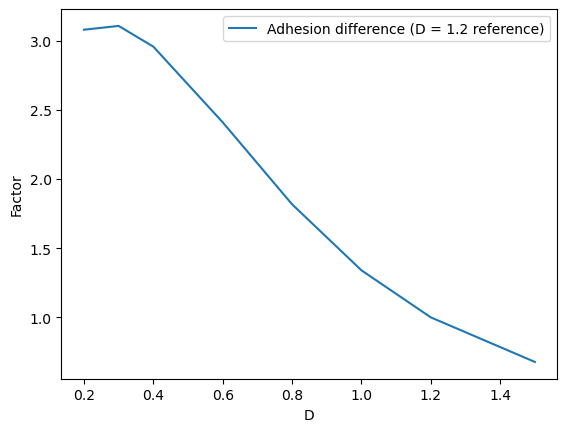

In [13]:
#from data
x=np.array([ 0.2,  0.3,   0.4,  0.6,  0.8,  1.0,  1.2,  1.5]) #from adh measure .cu
y=np.array([686.875,692.978, 659.61, 537.646, 405.432, 298.999, 223.128, 151.289])

z =  y/223.128

# plt.title("Applied adhesion in varying D regimes (kappa=5, lambda=5)")
plt.plot(x,z, label= "Adhesion difference (D = 1.2 reference)")

plt.legend()
plt.xlabel("D")
plt.ylabel("Factor")
plt.show()

# Frames

In [183]:
import tarfile
from PIL import Image

NX, NY = 512,512
TYPE_COLORS = {
    1: (0.0, 1.0, 1.0),  # cyan
    2: (0.0, 1.0, 0.0),  # grün
    3: (1.0, 0.0, 0.0),  # rot
    4: (1.0, 1.0, 0.0),  # gelb
    5: (0.0, 1.0, 0.0),  # grün
    6: (0.0, 1.0, 1.0),  # cyan
}

################################
# type funcs
################################
def get_cell_c_TS(cell_id):

    if cell_id >= 108:
        return (1.0, 0.0, 1.0)
    p = cell_id // 2 #which pair 
    part = cell_id % 2   #re/im
    
    if p % 3 == 0:
        return TYPE_COLORS[5] if part == 0 else TYPE_COLORS[2]
    elif p % 3 == 1:
        return TYPE_COLORS[4] if part == 0 else TYPE_COLORS[3]
    else:
        return TYPE_COLORS[6] if part == 0 else TYPE_COLORS[1]
    
################################################
def fields_to_rgb_area(fields, colours):

    rgb = np.zeros((NY, NX, 3), dtype=np.float32)

    for field, colour in zip(fields, colours):

        #border visible w. error
        f = ((field - 0.5) > 0).astype(np.float32)

        rgb[..., 0] += f * colour[0]
        rgb[..., 1] += f * colour[1]
        rgb[..., 2] += f * colour[2]

    rgb = np.clip(rgb, 0.0, 1.0)

    frame = (rgb * 255).astype(np.uint8)

    return frame
################################################
def fields_to_rgb(fields, colours, vmin=0, vmax=1):

    rgb = np.zeros((NY, NX, 3), dtype=np.float32)
    if vmax - vmin <= 1e-12:
        scale = 1.0
        offset = vmin
    else:
        scale = 1.0 / (vmax - vmin)
        offset = vmin
    for field,colour in zip(fields,colours):
        field_c = np.clip(field, vmin, vmax)
        f = (field_c - offset) * scale   
        f = np.clip(f, 0.0, 1.0)
        rgb[..., 0] += f * colour[0]
        rgb[..., 1] += f * colour[1]
        rgb[..., 2] += f * colour[2]
    rgb = np.clip(rgb, 0.0, 1.0)
    frame = (rgb * 255).astype(np.uint8)
    return frame

################################################
def fields_to_rgb_area_max(fields, colours):

    rgb = np.zeros((NY, NX, 3), dtype=np.float32)

    for field, colour in zip(fields, colours):

        #border visible w. error
        # f = ((field - 0.5) > 0).astype(np.float32)
        field_max = np.max(field)
        if field_max >=0.5:
            f = (field >= field_max - 0.5).astype(np.float32)
        else:
            f=0

        rgb[..., 0] += f * colour[0]
        rgb[..., 1] += f * colour[1]
        rgb[..., 2] += f * colour[2]

    rgb = np.clip(rgb, 0.0, 1.0)

    frame = (rgb * 255).astype(np.uint8)

    return frame

################################################


def fields_to_viridis(fields, vmin=0, vmax=1):

    rgb = np.zeros((NY, NX, 3), dtype=np.float32)
    cmap = plt.get_cmap("viridis")

    if vmax - vmin <= 1e-12:
        scale = 1.0
        offset = vmin
    else:
        scale = 1.0 / (vmax - vmin)
        offset = vmin

    for field in fields:
        field_c = np.clip(field, vmin, vmax)
        f = (field_c - offset) * scale
        f = np.clip(f, 0.0, 1.0)

        colour_field = cmap(f)[..., :3]

        rgb[..., 0] += f * colour_field[..., 0]
        rgb[..., 1] += f * colour_field[..., 1]
        rgb[..., 2] += f * colour_field[..., 2]

    rgb = np.clip(rgb, 0.0, 1.0)
    frame = (rgb * 255).astype(np.uint8)
    return frame


#loop for runs 
#RUN_DIR = Path(r"E:\MASTER THESIS\code\unity sweep\D-adh5")
# SAVE_DIR = Path(r"E:\MASTER THESIS\code\unity sweep\misc")
# SAVE_DIR.mkdir(parents=True, exist_ok=True)
end_frame = 45

dx = 0.3125
PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

df_save=[]

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

########################################################################################
################################
#one TAR file
################################
TAR_PATH = Path(r"E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_20_3_6_5_5_5_1.4843450557691142.tar.gz") #folders of .tar.gz runs

SAVE_DIR = Path( r"E:\MASTER THESIS\code\unity sweep\misc")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

fields = []
colours = []

print(f"Reading: {TAR_PATH}")

with tarfile.open(TAR_PATH, "r:gz") as tar:
    cells = [
        member
        for member in tar.getmembers()
        if member.isfile()
        and Path(member.name).name.startswith("rho")
        and Path(member.name).name.endswith(f"-t{end_frame}.txt")
    ]



    for cell in cells:
        filename = Path(cell.name).name
        match = PATTERN_RHO.match(filename)

        if match is None:
            continue

        extracted_file = tar.extractfile(cell)

        if extracted_file is None:
            continue

        rho = np.loadtxt(extracted_file)
        cell_id = int(match.group(1))

        fields.append(rho)
        colours.append(get_cell_c_TS(cell_id))

################################
#save image
################################
frame = fields_to_rgb_area_max(fields,colours)

run_name = TAR_PATH.name.removesuffix(".tar.gz")
output_file = SAVE_DIR / f"{run_name}_t{end_frame}_05.png"

Image.fromarray(frame).save(output_file)

print(f"Saved: {output_file}")





Reading: E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_20_3_6_5_5_5_1.4843450557691142.tar.gz
Saved: E:\MASTER THESIS\code\unity sweep\misc\out_debug_unity_adh5_D_20_3_6_5_5_5_1.4843450557691142_t45_05.png


# Mean Bundle shape

In [7]:
import tarfile

RUN_DIR = Path(r"E:\MASTER THESIS\code\unity sweep\D-adh5") #folders of .tar.gz runs
SAVE_DIR = Path(r"E:\MASTER THESIS\code\unity sweep")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

end_frame = 45
NX = 512
dx = 0.3125
PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

shape_l_all = []
bundle_centers_all = []

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

################################
#for every zipped directory 
################################
for tar_path in RUN_DIR.glob("*.tar.gz"):

    xs = []
    ys = []
    ts = []
    bs = []

    shape_bnd = []
    bundle_centers = []

    print(tar_path)

    with tarfile.open(tar_path, "r:gz") as tar:

        cells = [
            member for member in tar.getmembers()
            if member.isfile()
            and Path(member.name).name.startswith("rho")
            and Path(member.name).name.endswith(f"-t{end_frame}.txt")
        ]

        ################################
        #for every cell
        ################################
        for cell in cells:

            fname = Path(cell.name).name
            m = re.search(PATTERN_RHO, fname)

            if not m:
                continue

            f = tar.extractfile(cell)

            if f is None:
                continue

            rho = np.loadtxt(f)
            total_mass = np.sum(rho)

            if total_mass == 0 or not np.isfinite(total_mass):
                continue

            x_cm = np.sum(x_scaled * rho) / total_mass
            y_cm = np.sum(y_scaled * rho) / total_mass

            cell_id = int(m.group(1))

            xs.append(x_cm)
            ys.append(y_cm)
            ts.append(get_cell_type_TS(cell_id))
            bs.append(cell_id // 6)

    xs = np.array(xs)
    ys = np.array(ys)
    ts = np.array(ts)
    bs = np.array(bs)
    selected_bundles = {3, 7, 8, 9, 14, 16}
    ################################
    #for every bundle
    ################################
    for bundle in sorted(set(bs)):
        if bundle not in selected_bundles:
            continue
        mask = bs == bundle

        xs_b = xs[mask]
        ys_b = ys[mask]
        ts_b = ts[mask]

        order = np.argsort(ts_b)

        xs_sorted = xs_b[order]
        ys_sorted = ys_b[order]

        figure_bundle = list(zip(xs_sorted, ys_sorted))
        model = np.array(figure_bundle)

        if model.shape != ref.shape or not np.isfinite(model).all() or len(np.unique(model, axis=0)) != 6:
            continue
        shape_bnd.append(model)
        bundle_centers.append((bundle, np.mean(xs_b), np.mean(ys_b)))


    ################################
    #align bundles fpr mean shape
    ################################
    bund0 = shape_bnd[0] #use some
    aligned = []

    for shape in shape_bnd:
        _, shape_aligned, _ = procrustes(bund0, shape)
        aligned.append(shape_aligned)

    mean_shape = np.mean(np.stack(aligned), axis=0)

    ################################
    #run information
    ################################
    name = tar_path.stem.replace(".tar", "")
    m = re.search(r"_([0-9.]+)_(\d+)_(\d+)_([0-9.]+)$", name)

    if not m:
        continue

    rep = float(m.group(1))
    adh = int(m.group(2))
    dif = float(m.group(4))

    ################################
    #save
    ################################
    for pr, (x_mean, y_mean) in enumerate(mean_shape, start=1):

        shape_l_all.append({
            "run": name,
            "rep": rep,
            "dif": dif,
            "adh": adh,
            "pr": pr,
            "x": x_mean,
            "y": y_mean,
            "n_bundles": len(shape_bnd)
        })

    ################################
    #save bundle centers
    ################################
    for bundle, x_center, y_center in bundle_centers:

        bundle_centers_all.append({
            "run": name,
            "rep": rep,
            "dif": dif,
            "adh": adh,
            "bundle": bundle,
            "x": x_center,
            "y": y_center,
            "n_bundles": len(bundle_centers)
        })

################################
#save csvs
################################
pd.DataFrame(shape_l_all).to_csv(SAVE_DIR / "mean_shapes_unity_adh5_nob.csv",index=False)
pd.DataFrame(bundle_centers_all).to_csv(SAVE_DIR / "bundle_centers_adh5_nob.csv",index=False)


E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_0_3_6_5_5_5_0.8411106215679058.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_10_3_6_5_5_5_1.032392751536074.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_11_3_6_5_5_5_0.47538483954324245.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_12_3_6_5_5_5_1.469370680508597.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_13_3_6_5_5_5_0.5309700739485943.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_14_3_6_5_5_5_1.3106322130526427.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_15_3_6_5_5_5_1.1943795344279908.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_16_3_6_5_5_5_0.21899544273840021.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_17_3_6_5_5_5_0.24817904243134165.tar.gz
E:\MASTER THESIS\code\unity sweep\D-adh5\out_debug_unity_adh5_D_18_3_6_5_

# Shape comparison 

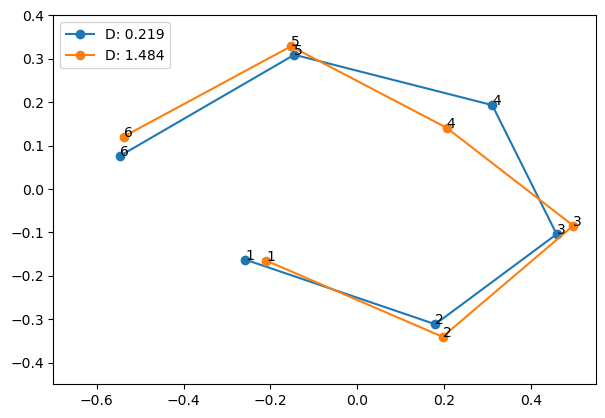

Lowest: out_debug_ver2b_adh5_D_16_3_6_5_5_5_0.21899544273840021 0.2189954427384002
Highest: out_debug_ver2b_adh5_D_20_3_6_5_5_5_1.4843450557691142 1.4843450557691142


In [29]:
################################
#lowest and highest dif bundle shapes
################################
# shapes = pd.read_csv("mean_shape_and_bundles/mean_shapes_unity_adh5_nob.csv",header=0)
shapes = pd.read_csv("mean_shape_and_bundles/mean_shapes_ver2b_adh5_nob.csv",header=0)
# shapes=shapes[shapes["dif"]>=0.5]
lowest_run = shapes.loc[shapes["dif"].idxmin(), "run"]
highest_run = shapes.loc[shapes["dif"].idxmax(), "run"]
lowest = shapes[shapes["run"] == lowest_run].sort_values("pr")
highest = shapes[shapes["run"] == highest_run].sort_values("pr")

lowest_shape = lowest[["x", "y"]].to_numpy()
highest_shape = highest[["x", "y"]].to_numpy()

lowest_shape, highest_shape, _ = procrustes(lowest_shape, highest_shape)

fig, ax = plt.subplots(figsize=(7, 5))

for shape, label, dif in [(lowest_shape, "D", lowest["dif"].iloc[0]), (highest_shape, "D", highest["dif"].iloc[0])]:
    ax.plot(shape[:, 0], -shape[:, 1], marker="o", label=f"{label}: {dif:.4g}")
    for i, (x, y) in enumerate(shape, start=1): 
        ax.text(x, -y, str(i))

# ax.set_title("Lowest and highest dif shapes, adh = 5")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.xlim(-0.7,0.55)
plt.ylim(-0.45,0.4)
plt.show()

print("Lowest:", lowest_run, lowest["dif"].iloc[0])
print("Highest:", highest_run, highest["dif"].iloc[0])

In [83]:
# shapes = pd.read_csv( "unity sweep/mean_shapes_unity_adh5_nob.csv", header=0)
# 
# min_adh = shapes["adh"].min()
# max_adh = shapes["adh"].max()
# 
# min_adh_data = shapes[np.isclose(shapes["adh"], min_adh)]
# max_adh_data = shapes[np.isclose(shapes["adh"], max_adh)]
# min_adh_run = min_adh_data.loc[min_adh_data["dif"].idxmax(), "run"]
# max_adh_run = max_adh_data.loc[max_adh_data["dif"].idxmax(), "run"]

In [31]:
#ini frame from endstaet
null =pd.read_csv( "mean_shape_and_bundles/mean_shapes_unity_adh5_null.csv", header=0)
null_run = null.loc[null["dif"].idxmin(), "run"]
nulls = null[null["run"] == null_run].sort_values("pr")
null_shape = nulls[["x", "y"]].to_numpy()

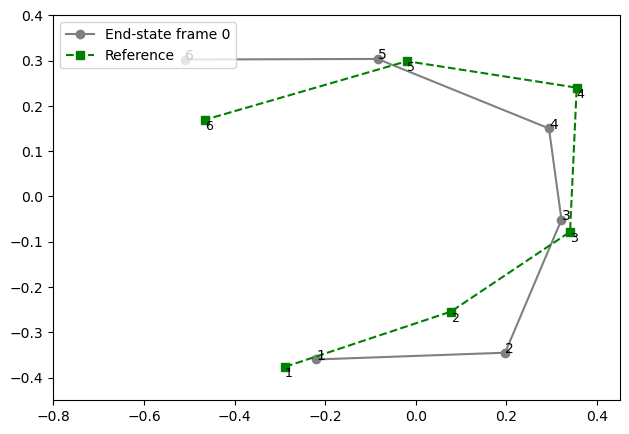

In [17]:
################################
#all bio
################################
null_aligned,ref_NULL,_ = procrustes(null_shape, ref)
# ref_low_aligned, lowest_aligned, _ = procrustes(ref, lowest_shape)
# _, high_aligned, _ = procrustes(ref, highest_shape)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(null_aligned[:, 0], -null_aligned[:, 1], marker="o",label=f"End-state frame 0",color="grey")
ax.plot(ref_NULL[:, 0], -ref_NULL[:, 1], marker="s", linestyle="--", label="Reference",color="green")
# ax.plot(lowest_aligned[:, 0], -lowest_aligned[:, 1], marker="o",label=f"D = {lowest['dif'].iloc[0]:.4g}",color="C0")
# ax.plot(high_aligned[:, 0], -high_aligned[:, 1], marker="o", label=f"D = {highest['dif'].iloc[0]:.4g}",color="C1")
# ax.plot(ref_low_aligned[:, 0], -ref_low_aligned[:, 1], marker="s", linestyle="--", label="Reference",color="green")

# for i, (x, y) in enumerate(high_aligned, start=1):
#     ax.text(x, -y, str(i))
# for i, (x, y) in enumerate(lowest_aligned, start=1):
#     ax.text(x, -y, str(i))
for i, (x, y) in enumerate(null_aligned, start=1):
    ax.text(x, -y, str(i))
# for t, (x, y) in zip(ref_ts, ref_low_aligned):
#     ax.text(x, -y, str(t), fontsize=9, ha="left", va="top")
for t, (x, y) in zip(ref_ts, ref_NULL):
    ax.text(x, -y, str(t), fontsize=9, ha="left", va="top")

# ax.set_title("Lowest dif vs reference, adh = 5")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.xlim(-0.8,0.45)
plt.ylim(-0.45,0.4)
# plt.tight_layout()
plt.show()

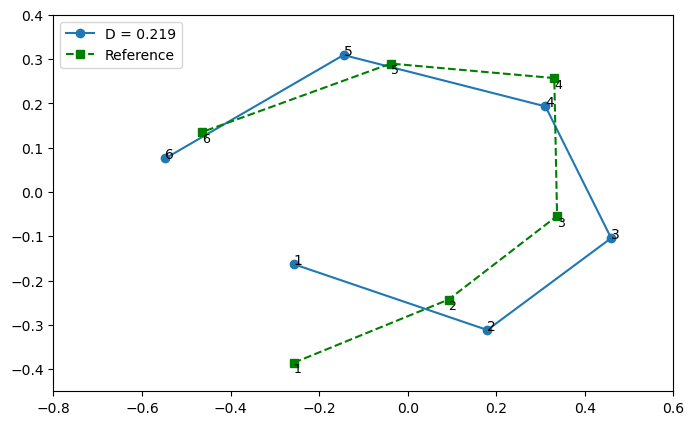

In [12]:
################################
#low bio
################################
lowest_aligned, ref_low_aligned, _ = procrustes(lowest_shape, ref)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(lowest_aligned[:, 0], -lowest_aligned[:, 1], marker="o",label=f"D = {lowest['dif'].iloc[0]:.4g}")
ax.plot(ref_low_aligned[:, 0], -ref_low_aligned[:, 1], marker="s", linestyle="--", label="Reference",color="green")


for i, (x, y) in enumerate(lowest_aligned, start=1):
    ax.text(x, -y, str(i))
for t, (x, y) in zip(ref_ts, ref_low_aligned):
    ax.text(x, -y, str(t), fontsize=9, ha="left", va="top")

# ax.set_title("Lowest dif vs reference, adh = 5")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.xlim(-0.8,0.6)
plt.ylim(-0.45,0.4)
# plt.tight_layout()
plt.show()

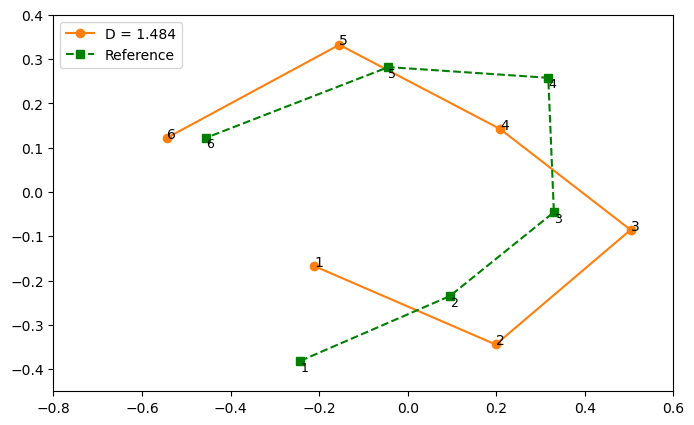

In [13]:
################################
#high bio
################################
high_aligned, ref_low_aligned, _ = procrustes(highest_shape, ref)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(high_aligned[:, 0], -high_aligned[:, 1], marker="o", label=f"D = {highest['dif'].iloc[0]:.4g}",color="C1")
ax.plot(ref_low_aligned[:, 0], -ref_low_aligned[:, 1], marker="s", linestyle="--", label="Reference",color="green")

for i, (x, y) in enumerate(high_aligned, start=1):
    ax.text(x, -y, str(i))
for t, (x, y) in zip(ref_ts, ref_low_aligned):
    ax.text(x, -y, str(t), fontsize=9, ha="left", va="top")

# ax.set_title("Lowest dif vs reference, adh = 5")

ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.xlim(-0.8,0.6)
plt.ylim(-0.45,0.4)
# plt.tight_layout()
plt.show()

In [16]:
shapes

,run,rep,dif,adh,point,x,y,n_bundles
0,out_debug_ver2b_D-rep5_0_3_6_5_2_2_0.347883874...,5.0,0.347884,2,1,-0.501852,-0.143150,18
1,out_debug_ver2b_D-rep5_0_3_6_5_2_2_0.347883874...,5.0,0.347884,2,2,-0.121482,-0.322350,18
2,out_debug_ver2b_D-rep5_0_3_6_5_2_2_0.347883874...,5.0,0.347884,2,3,0.286276,-0.171365,18
3,out_debug_ver2b_D-rep5_0_3_6_5_2_2_0.347883874...,5.0,0.347884,2,4,0.437353,0.139682,18
4,out_debug_ver2b_D-rep5_0_3_6_5_2_2_0.347883874...,5.0,0.347884,2,5,0.154560,0.330210,18
...,...,...,...,...,...,...,...,...
535,out_debug_ver2b_D-rep5_9_3_6_5_2_2_1.445540169...,5.0,1.445540,2,2,-0.113542,-0.348927,18
536,out_debug_ver2b_D-rep5_9_3_6_5_2_2_1.445540169...,5.0,1.445540,2,3,0.243083,-0.150556,18
537,out_debug_ver2b_D-rep5_9_3_6_5_2_2_1.445540169...,5.0,1.445540,2,4,0.446096,0.159957,18
538,out_debug_ver2b_D-rep5_9_3_6_5_2_2_1.445540169...,5.0,1.445540,2,5,0.122950,0.349074,18


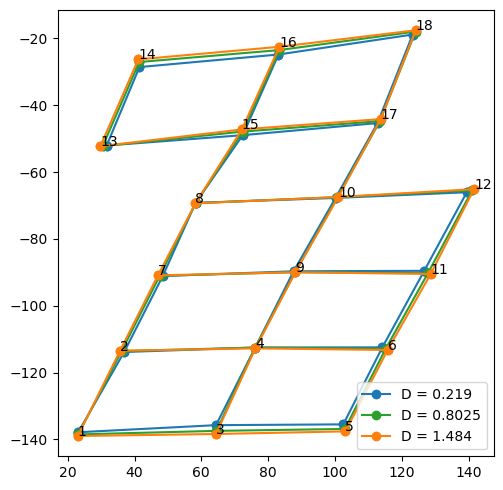

In [32]:
################################
#lowest and highest dif grid shapes
################################

connections = [
    [0, 1, 6, 7, 14, 15],
    [2, 3, 8, 9, 16, 17],
    [4, 5, 10, 11],
    [12, 13],
    [0, 2, 4],
    [1, 3, 5],
    [6, 8, 10],
    [7, 9, 11],
    [12, 14, 16],
    [13, 15, 17]
]

# connections = [
#     [ 7, 14],
#     [ 3, 8, 9, 16],
#     [7, 9],
#     [ 14, 16]
# ]
shapes = pd.read_csv("mean_shape_and_bundles/bundle_centers_unity_adh5.csv", header=0)
# shapes=shapes[shapes["dif"]>=0.5]
lowest_run = shapes.loc[shapes["dif"].idxmin(), "run"]
highest_run = shapes.loc[shapes["dif"].idxmax(), "run"]
lowest = shapes[shapes["run"] == lowest_run].sort_values("bundle")
highest = shapes[shapes["run"] == highest_run].sort_values("bundle")

lowest_shape = lowest[["x", "y"]].to_numpy()
highest_shape = highest[["x", "y"]].to_numpy()

#08 shape
mid_dif = 0.8025400775017721
mid_run = shapes.loc[(shapes["dif"] - mid_dif).abs().idxmin(), "run"]
mid = shapes[shapes["run"] == mid_run].sort_values("bundle")
mid_shape = mid[["x", "y"]].to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))


for j, conn in enumerate(connections):
    xy = lowest_shape[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o", label=f"D = {lowest['dif'].iloc[0]:.4g}" if j == 0 else None, color="C0")
for j, conn in enumerate(connections):
    xy = mid_shape[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o", label=f"D = {mid['dif'].iloc[0]:.4g}" if j == 0 else None, color="C2")
for j, conn in enumerate(connections):
    xy = highest_shape[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o", label=f"D = {highest['dif'].iloc[0]:.4g}" if j == 0 else None, color="C1")    
for i, (x, y) in enumerate(highest_shape, start=1):
    ax.text(x, -y, str(i))
# ax.set_title("Lowest and highest dif shapes, adh = 5")
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


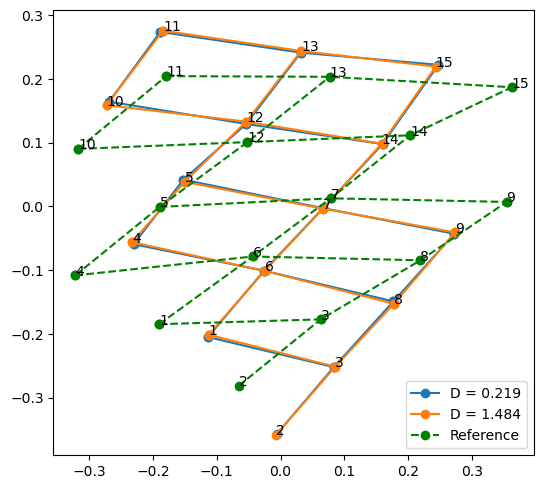

In [33]:
################################
#lowest and highest dif grid shapes w bio
################################
connections = [
    [ 6, 7, 14, 15],
    [ 3, 8, 9, 16, 17],
    [4, 5, 10, 11],
    [12, 13],
    [ 3, 5],
    [6, 8, 10],
    [7, 9, 11],
    [12, 14, 16],
    [13, 15, 17]
]

# connections = [
#     [ 7, 14],
#     [ 3, 8, 9, 16],
#     [7, 9],
#     [ 14, 16]
# ]

shapes = pd.read_csv("mean_shape_and_bundles/bundle_centers_unity_adh5.csv", header=0)
# shapes=shapes[shapes["dif"]>=0.5]
lowest_run = shapes.loc[shapes["dif"].idxmin(), "run"]
highest_run = shapes.loc[shapes["dif"].idxmax(), "run"]
lowest = shapes[shapes["run"] == lowest_run].sort_values("bundle")
highest = shapes[shapes["run"] == highest_run].sort_values("bundle")

lowest_shape = lowest[["x", "y"]].to_numpy()
highest_shape = highest[["x", "y"]].to_numpy()

#bio shape
bundle_cs_f2 = normal_bio_fl[["x", "y_flip"]].to_numpy()
bio_low, low_aligned, _ = procrustes(bundle_cs_f2, lowest_shape[3:])
bio_high, high_aligned, _ = procrustes(bundle_cs_f2, highest_shape[3:])
connections_aligned = [[i - 3 for i in conn] for conn in connections]
fig, ax = plt.subplots(figsize=(7, 5))


for j, conn in enumerate(connections_aligned):
    xy = low_aligned[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o", label=f"D = {lowest['dif'].iloc[0]:.4g}" if j == 0 else None, color="C0")
for j, conn in enumerate(connections_aligned):
    xy = high_aligned[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o", label=f"D = {highest['dif'].iloc[0]:.4g}" if j == 0 else None, color="C1")  
for j, conn in enumerate(connections_aligned):
    xy = bio_high[conn]
    ax.plot(xy[:, 0], -xy[:, 1], marker="o",linestyle="--", label=f"Reference" if j == 0 else None, color="green")
  
for i, (x, y) in enumerate(high_aligned, start=1):
    ax.text(x, -y, str(i))
for i, (x, y) in enumerate(bio_high, start=1):
    ax.text(x, -y, str(i))
# ax.set_title("Lowest and highest dif shapes, adh = 5")
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [164]:
normal_bio_fl

,bundle,x,y,y_flip
0,3,372.379902,-499.260825,499.260825
1,4,468.963644,-574.177492,574.177492
2,5,568.668913,-493.385008,493.385008
3,6,270.471201,-439.951797,439.951797
4,7,372.930760,-356.772263,356.772263
5,8,486.040237,-416.999387,416.999387
6,9,580.787786,-346.305964,346.305964
7,10,689.857639,-421.589869,421.589869
8,11,794.520629,-350.712827,350.712827
9,12,273.959967,-286.262459,286.262459


# Versions


In [18]:
import sys
print(sys.version)

3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


In [20]:
!pip show numpy pandas matplotlib scipy pillow imageio shapesimilarity

Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: C:\Users\Sebas\anaconda3\Lib\site-packages
Requires: 
Required-by: anndata, biopython, Bottleneck, chex, clarabel, contourpy, cvxpy, flax, gseapy, hyperopt, ImageIO, jax, jaxlib, jraph, keras, matplotlib, mkl_fft, mkl_random, ml_dtypes, numexpr, open3d, optax, optuna, orbax-checkpoint, osqp, pandas, pingouin, scanpy, scikit-image, scikit-misc, scikit-optimize, scipy, scs, scvi, tensorboard, tensorflow_intel, tensorstore, tifffile, torch-geometric, treescope, umap-learn
---
Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData